In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df= pd.read_csv("/content/태림_통합데이터3.csv")

# 그냥 기본 EDA

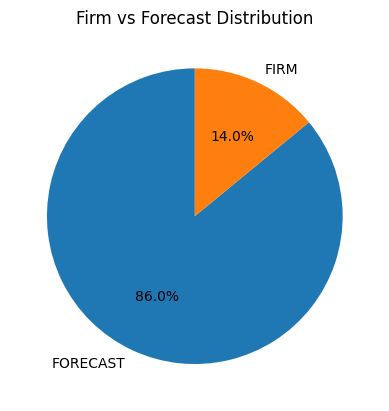

In [5]:
plt.figure()

df['Firm/Forecast'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Firm vs Forecast Distribution")
plt.ylabel("")
plt.show()

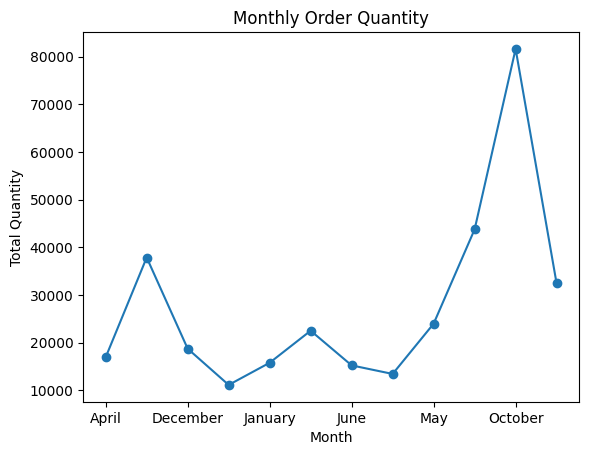

In [6]:
month_qty = df.groupby('Month')['Quantity'].sum()

plt.figure()
month_qty.plot(kind='line', marker='o')

plt.title("Monthly Order Quantity")
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.show()

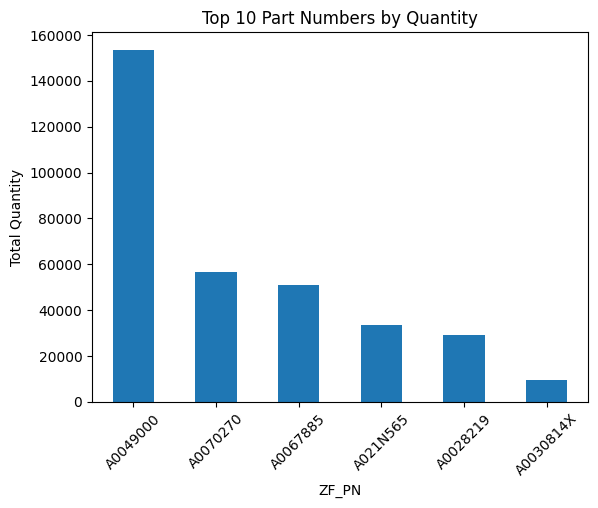

In [7]:
top_pn = df.groupby('ZF_PN')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_pn.plot(kind='bar')

plt.title("Top 10 Part Numbers by Quantity")
plt.xlabel("ZF_PN")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)

plt.show()

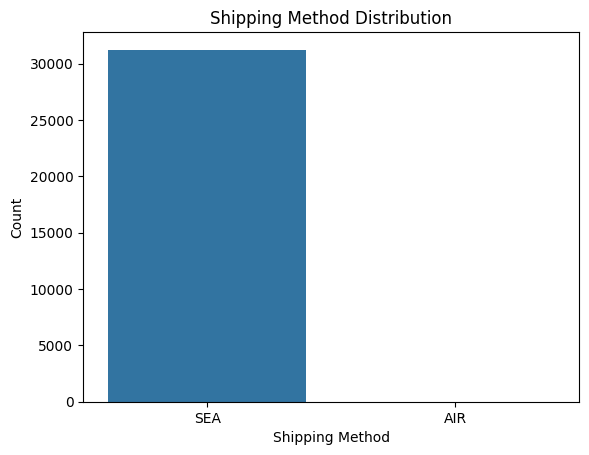

In [8]:
plt.figure()

sns.countplot(data=df, x="Shipping_Inst")

plt.title("Shipping Method Distribution")
plt.xlabel("Shipping Method")
plt.ylabel("Count")

plt.show()

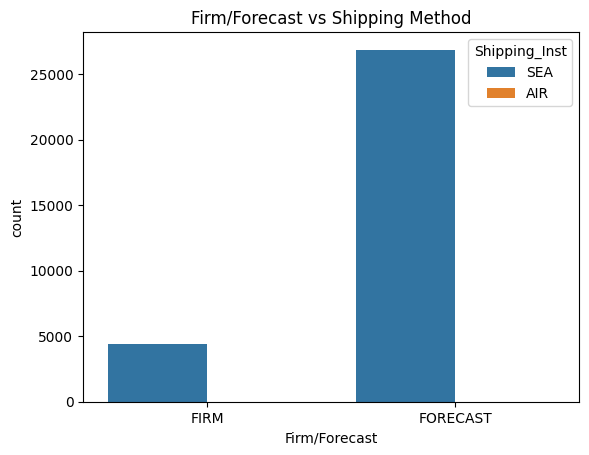

In [10]:
plt.figure()

sns.countplot(
    data=df,
    x="Firm/Forecast",
    hue="Shipping_Inst"
)

plt.title("Firm/Forecast vs Shipping Method")

plt.show()

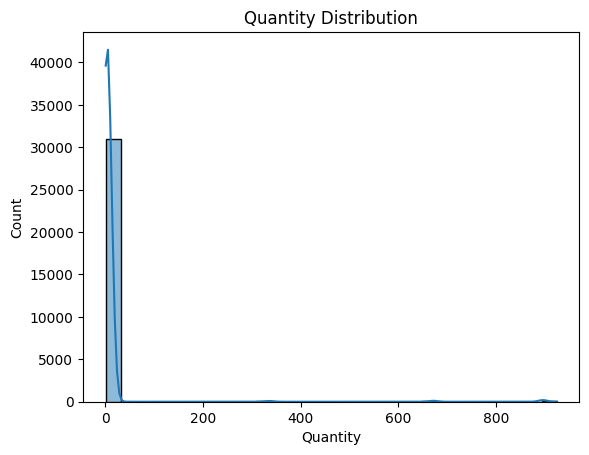

In [11]:
plt.figure()

sns.histplot(
    df["Quantity"],
    bins=30,
    kde=True
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")

plt.show()

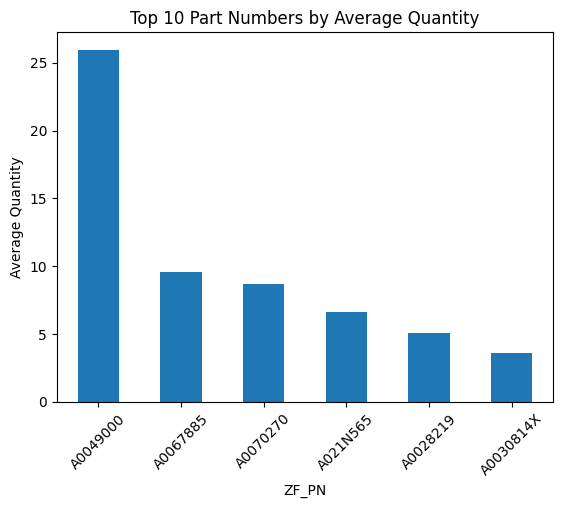

In [12]:
avg_qty = df.groupby("ZF_PN")["Quantity"].mean().sort_values(ascending=False).head(10)

plt.figure()

avg_qty.plot(kind="bar")

plt.title("Top 10 Part Numbers by Average Quantity")
plt.xlabel("ZF_PN")
plt.ylabel("Average Quantity")

plt.xticks(rotation=45)

plt.show()

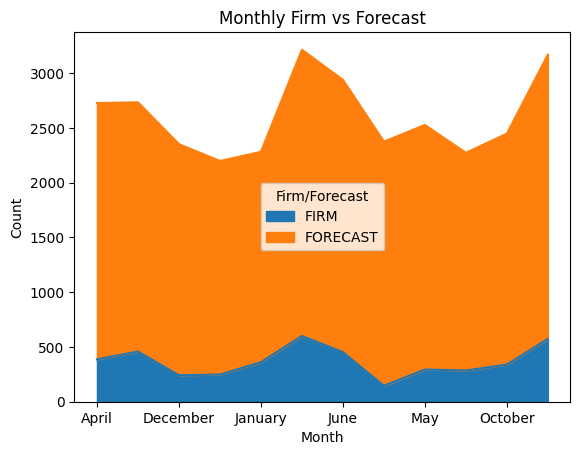

In [13]:
month_status = df.groupby(["Month","Firm/Forecast"]).size().unstack()

month_status.plot(kind="area", stacked=True)

plt.title("Monthly Firm vs Forecast")
plt.xlabel("Month")
plt.ylabel("Count")

plt.show()

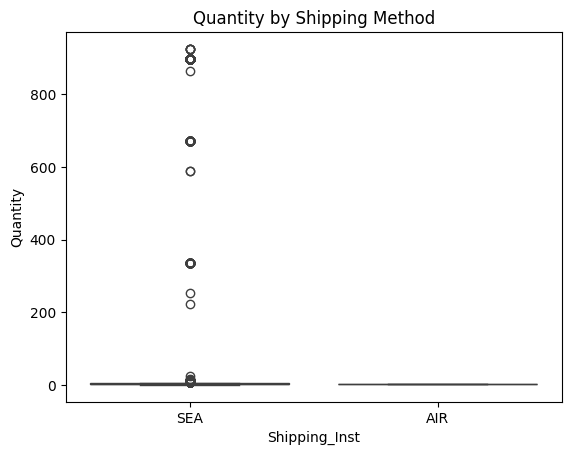

In [14]:
plt.figure()

sns.boxplot(
    data=df,
    x="Shipping_Inst",
    y="Quantity"
)

plt.title("Quantity by Shipping Method")

plt.show()

# 다른 EDA

Forecast → Firm 전환 분석

In [16]:
# install Hangul font

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,407 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [3]:
plt.rc('font', family='NanumBarunGothic')

          구분    건수
0  Forecast만  1431
1      Firm만   734
2     둘 다 존재  1364


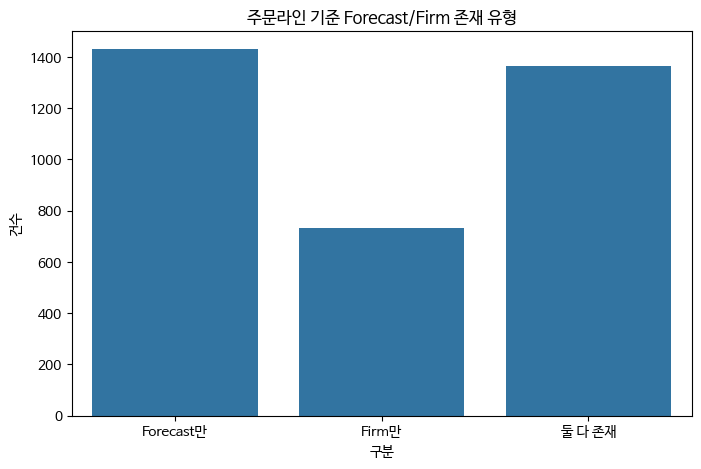

In [6]:
key_cols = ["ZF_PN", "Order", "ID_Release", "Quantity"]

line_status = (
    df.groupby(key_cols)["Firm/Forecast"]
      .agg(lambda x: set(x.dropna()))
      .reset_index(name="status_set")
)

line_status["has_forecast"] = line_status["status_set"].apply(lambda x: "FORECAST" in x)
line_status["has_firm"] = line_status["status_set"].apply(lambda x: "FIRM" in x)

summary = pd.DataFrame({
    "구분": ["Forecast만", "Firm만", "둘 다 존재"],
    "건수": [
        ((line_status["has_forecast"]) & (~line_status["has_firm"])).sum(),
        ((~line_status["has_forecast"]) & (line_status["has_firm"])).sum(),
        ((line_status["has_forecast"]) & (line_status["has_firm"])).sum(),
    ]
})

print(summary)

plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="구분", y="건수")
plt.title("주문라인 기준 Forecast/Firm 존재 유형")
plt.show()

- Forecast로만 끝난 라인이 많은지

- Firm으로 바로 간 라인이 많은지

- Forecast와 Firm이 둘 다 나타나는 라인이 얼마나 되는지

Forecast 포함 주문라인 중 Firm까지 이어진 비율: 48.80%


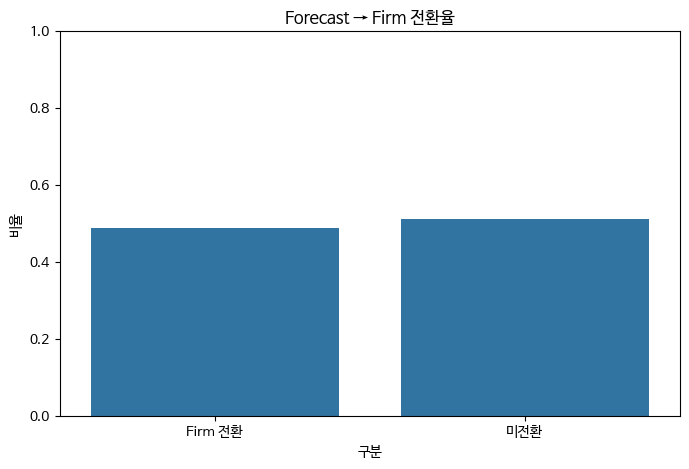

In [7]:
forecast_lines = line_status[line_status["has_forecast"]].copy()
conversion_rate = forecast_lines["has_firm"].mean()

print(f"Forecast 포함 주문라인 중 Firm까지 이어진 비율: {conversion_rate:.2%}")

conv_df = pd.DataFrame({
    "구분": ["Firm 전환", "미전환"],
    "비율": [
        conversion_rate,
        1 - conversion_rate
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(data=conv_df, x="구분", y="비율")
plt.title("Forecast → Firm 전환율")
plt.ylim(0, 1)
plt.show()

       ZF_PN  forecast_lines  converted_lines  conversion_rate
0   A0028219             297              230         0.774411
2   A0049000             373              213         0.571046
1  A0030814X             238              135         0.567227
3   A0067885             618              286         0.462783
4   A0070270             705              294         0.417021
5   A021N565             564              206         0.365248


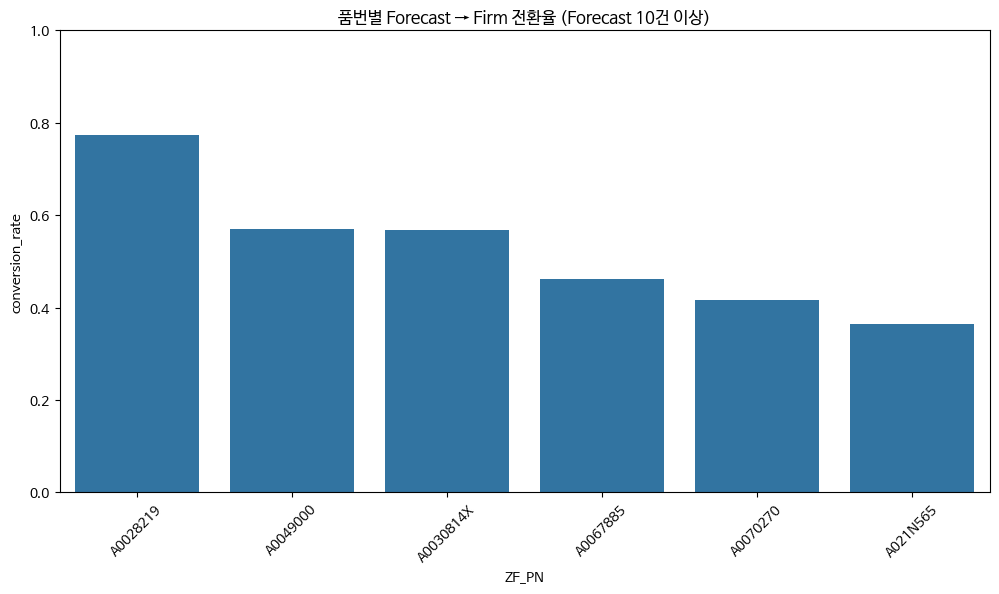

In [8]:
pn_conv = (
    line_status.groupby("ZF_PN")
    .agg(
        total_lines=("ZF_PN", "size"),
        forecast_lines=("has_forecast", "sum"),
        converted_lines=("has_firm", lambda x: np.nan)  # placeholder
    )
)

# forecast 포함된 라인만 대상으로 다시 계산
tmp = line_status[line_status["has_forecast"]].copy()
pn_conv2 = (
    tmp.groupby("ZF_PN")
       .agg(
           forecast_lines=("has_forecast", "size"),
           converted_lines=("has_firm", "sum")
       )
       .reset_index()
)

pn_conv2["conversion_rate"] = pn_conv2["converted_lines"] / pn_conv2["forecast_lines"]
pn_conv2 = pn_conv2.sort_values("conversion_rate", ascending=False)

print(pn_conv2.head(20))

top_conv = pn_conv2[pn_conv2["forecast_lines"] >= 10].sort_values("conversion_rate", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_conv, x="ZF_PN", y="conversion_rate")
plt.title("품번별 Forecast → Firm 전환율 (Forecast 10건 이상)")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

- A0028219 → 매우 안정적인 수요
- A021N565 → 불확실한 수요

    month_num  forecast_lines  converted_lines  conversion_rate
0           1             141               80         0.567376
1           2             128               59         0.460938
2           3             130               39         0.300000
3           4             231              161         0.696970
4           5             270              124         0.459259
5           6             212              133         0.627358
6           7             331              230         0.694864
7           8             237              130         0.548523
8           9             301              132         0.438538
9          10             358               89         0.248603
10         11             205               95         0.463415
11         12             251               92         0.366534


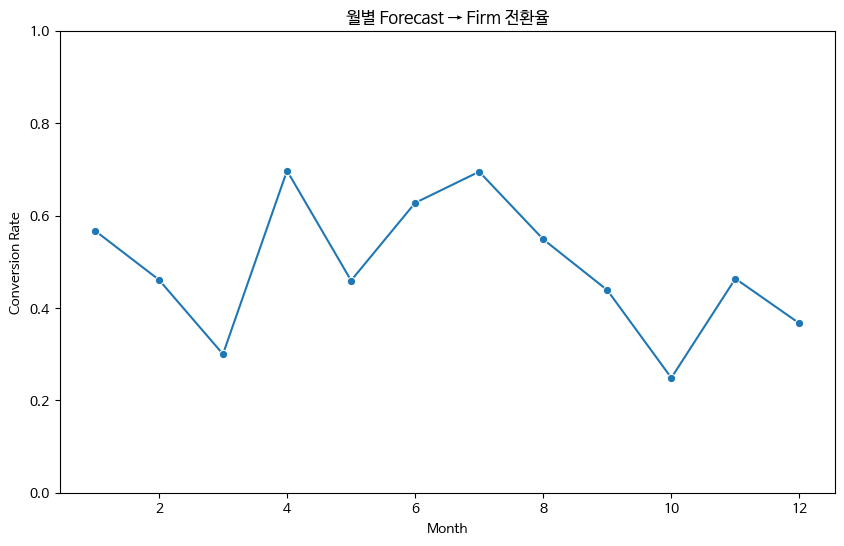

In [10]:
# 날짜 컬럼 생성
df["date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-" +
    df["Day"].astype(str),
    errors="coerce"
)

df[["Year","Month","Day","date"]].head()

# 주문라인 단위 대표 월: 가장 이른 date의 월 사용
line_first_date = (
    df.groupby(key_cols)["date"]
      .min()
      .reset_index(name="first_date")
)

line_status_month = line_status.merge(line_first_date, on=key_cols, how="left")
line_status_month["month_num"] = line_status_month["first_date"].dt.month

monthly_conv = (
    line_status_month[line_status_month["has_forecast"]]
    .groupby("month_num")
    .agg(
        forecast_lines=("has_forecast", "size"),
        converted_lines=("has_firm", "sum")
    )
    .reset_index()
)

monthly_conv["conversion_rate"] = monthly_conv["converted_lines"] / monthly_conv["forecast_lines"]
print(monthly_conv)

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_conv, x="month_num", y="conversion_rate", marker="o")
plt.title("월별 Forecast → Firm 전환율")
plt.xlabel("Month")
plt.ylabel("Conversion Rate")
plt.ylim(0, 1)
plt.show()

- Forecast 신뢰도는 시간에 따라 변함
- 4월, 7월 -> 높은 달, 3월, 10월 -> 낮은 달
- 가능한 원인 1. 생산 계획 2. 고객 주문 패턴 3. 시즌성

count    1364.000000
mean     -144.441349
std       112.666820
min      -655.000000
25%      -177.250000
50%      -109.000000
75%       -79.000000
max        -7.000000
Name: date_diff_days, dtype: float64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


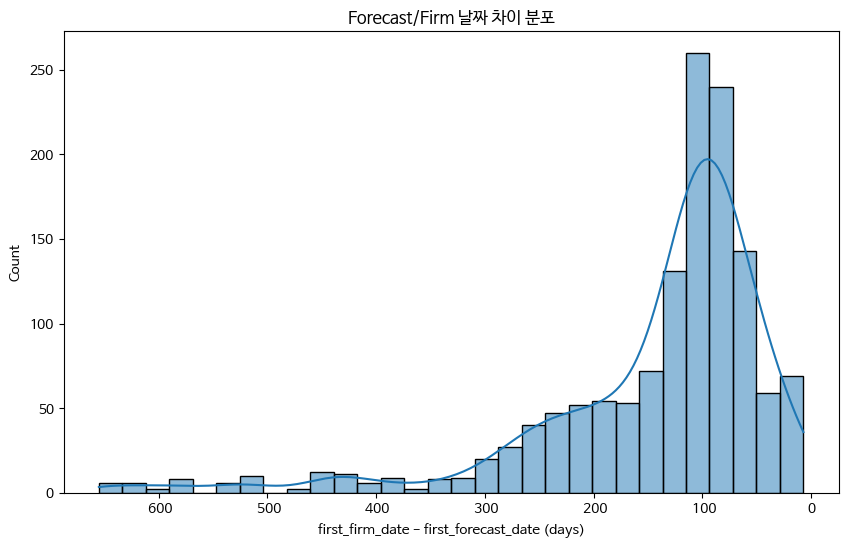

In [11]:
line_dates = (
    df.groupby(key_cols)
      .apply(
          lambda x: pd.Series({
              "first_forecast_date": x.loc[x["Firm/Forecast"].eq("FORECAST"), "date"].min(),
              "first_firm_date": x.loc[x["Firm/Forecast"].eq("FIRM"), "date"].min()
          }),
          include_groups=False
      )
      .reset_index()
)

line_dates["date_diff_days"] = (
    line_dates["first_firm_date"] - line_dates["first_forecast_date"]
).dt.days

valid_diff = line_dates["date_diff_days"].dropna()

print(valid_diff.describe())

plt.figure(figsize=(10,6))
sns.histplot(valid_diff, bins=30, kde=True)
plt.title("Forecast/Firm 날짜 차이 분포")
plt.xlabel("first_firm_date - first_forecast_date (days)")
plt.show()

- 보통 Forecast-> Firm 전환까지 약 2~5개월 정도 걸린다고 본다.
- 하지만 이 날짜는 잘 모르기 때문에 정확한 전환 시간은 아니라고 판단.

- Forecast 데이터 중 약 49%만 실제 Firm 주문으로 전환되었으며,
제품별 및 시기별로 전환율이 크게 차이나는 패턴을 확인할 수 있다.
이는 Forecast 데이터를 기반으로 Firm 전환 여부를 예측하는 모델 개발해도 되지 않을까 에 대한 설명.

# Firm 주문 → Shipping 방식 분석

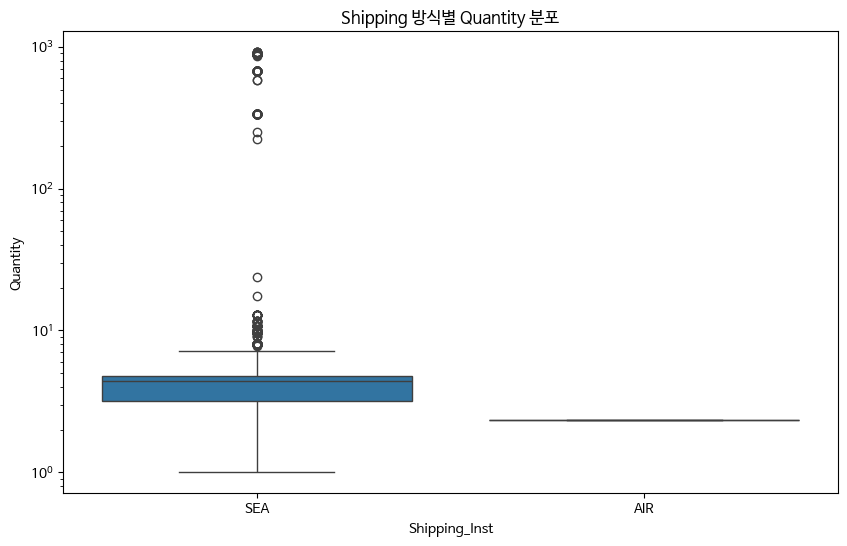

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Shipping_Inst", y="Quantity")
plt.title("Shipping 방식별 Quantity 분포")
plt.yscale("log")  # 수량 편차가 크면 로그축이 보기 편함
plt.show()

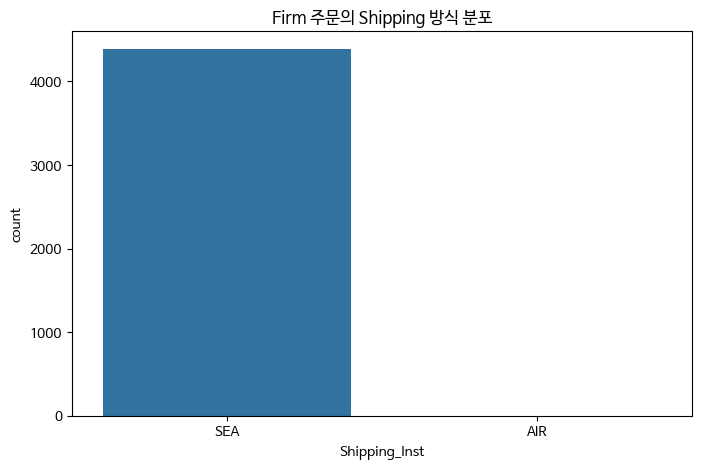

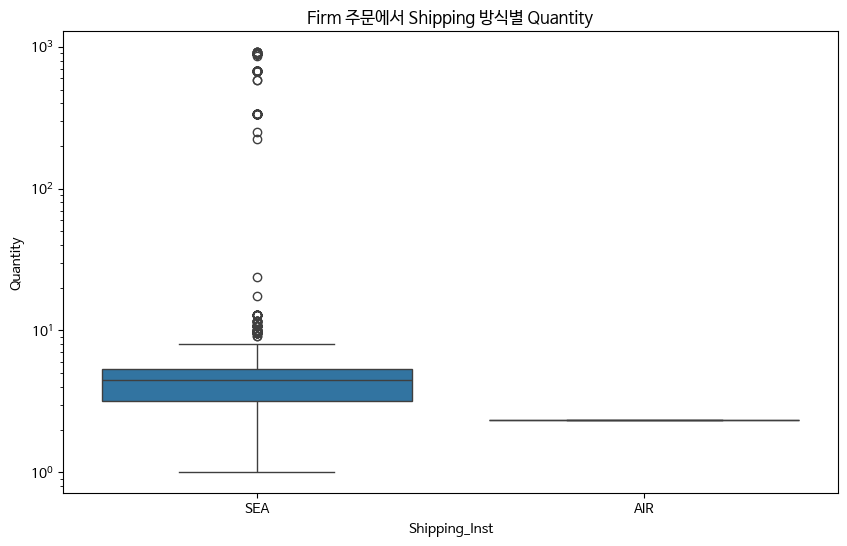

In [15]:
firm_df = df[df["Firm/Forecast"] == "FIRM"].copy()

plt.figure(figsize=(8,5))
sns.countplot(data=firm_df, x="Shipping_Inst")
plt.title("Firm 주문의 Shipping 방식 분포")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=firm_df, x="Shipping_Inst", y="Quantity")
plt.title("Firm 주문에서 Shipping 방식별 Quantity")
plt.yscale("log")
plt.show()

# Part Number별 수요 안정성 분석

In [16]:
sku_stats = (
    df.groupby("ZF_PN")["Quantity"]
      .agg(["count", "mean", "std", "min", "max"])
      .reset_index()
)

sku_stats["cv"] = sku_stats["std"] / sku_stats["mean"]
sku_stats = sku_stats.sort_values("cv", ascending=False)

print(sku_stats.head(20))

       ZF_PN  count       mean         std    min    max        cv
4   A0070270   6514   8.702852   56.619989  1.008  924.0  6.505912
3   A0067885   5298   9.582659   58.314275  1.008  672.0  6.085396
5   A021N565   5067   6.619936   39.640801  1.008  672.0  5.988094
2   A0049000   5914  25.954202  134.990660  1.760  896.0  5.201110
1  A0030814X   2725   3.583413    1.108088  1.600    9.6  0.309227
0   A0028219   5720   5.078042    1.259039  1.600   12.8  0.247938


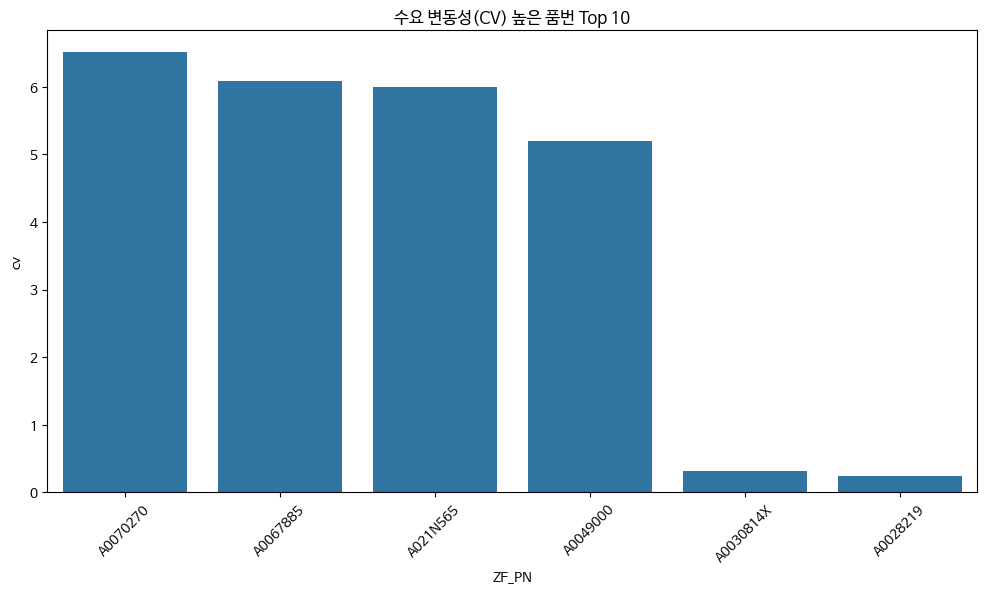

In [17]:
top_cv = sku_stats[sku_stats["count"] >= 10].head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_cv, x="ZF_PN", y="cv")
plt.title("수요 변동성(CV) 높은 품번 Top 10")
plt.xticks(rotation=45)
plt.show()

- A0028219 A0030814X -> 주문량 일정, 수요 예측 쉬움
- A0070270 A0067885 A021N565 A0049000 -> 주문량 변동 매우 큼, 예측 어려움

- 품번별 수요 변동성을 분석한 결과 일부 SKU는 매우 안정적인 수요 패턴을 보였지만, 특정 품번은 CV가 5 이상으로 매우 높은 변동성을 보였다. 이는 제품별로 서로 다른 생산 및 재고 전략이 필요함을 의미

has_invoice    False  True 
Firm/Forecast              
FIRM            1324   3063
FORECAST       26851      0


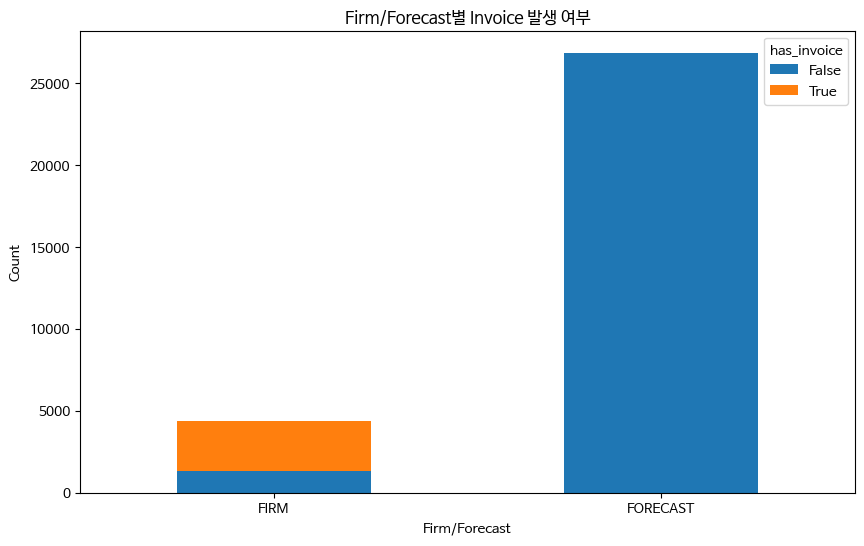

In [19]:
df["has_invoice"] = df["Shipped_Invoice"].notna() & (df["Shipped_Invoice"].astype(str).str.strip() != "")

invoice_ct = pd.crosstab(df["Firm/Forecast"], df["has_invoice"])
print(invoice_ct)

invoice_ct.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Firm/Forecast별 Invoice 발생 여부")
plt.xlabel("Firm/Forecast")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

- Forecast = 수요 예측, Firm = 확정 주문, Invoice = 실제 출하

has_invoice       False     True 
Firm/Forecast                    
FIRM           0.301801  0.698199
FORECAST       1.000000  0.000000


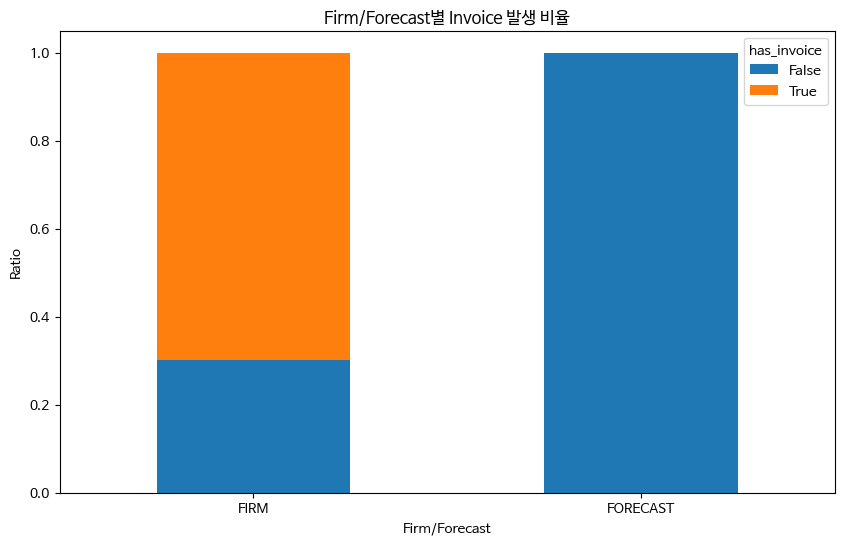

In [20]:
invoice_ratio = pd.crosstab(df["Firm/Forecast"], df["has_invoice"], normalize="index")
print(invoice_ratio)

invoice_ratio.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Firm/Forecast별 Invoice 발생 비율")
plt.xlabel("Firm/Forecast")
plt.ylabel("Ratio")
plt.xticks(rotation=0)
plt.show()

- 약 70% -> 실제 invoice 발생

       ZF_PN  total_rows  invoice_rows  invoice_rate
1  A0030814X        2725           383      0.140550
0   A0028219        5720           608      0.106294
3   A0067885        5298           527      0.099471
2   A0049000        5914           562      0.095029
4   A0070270        6514           562      0.086276
5   A021N565        5067           421      0.083087


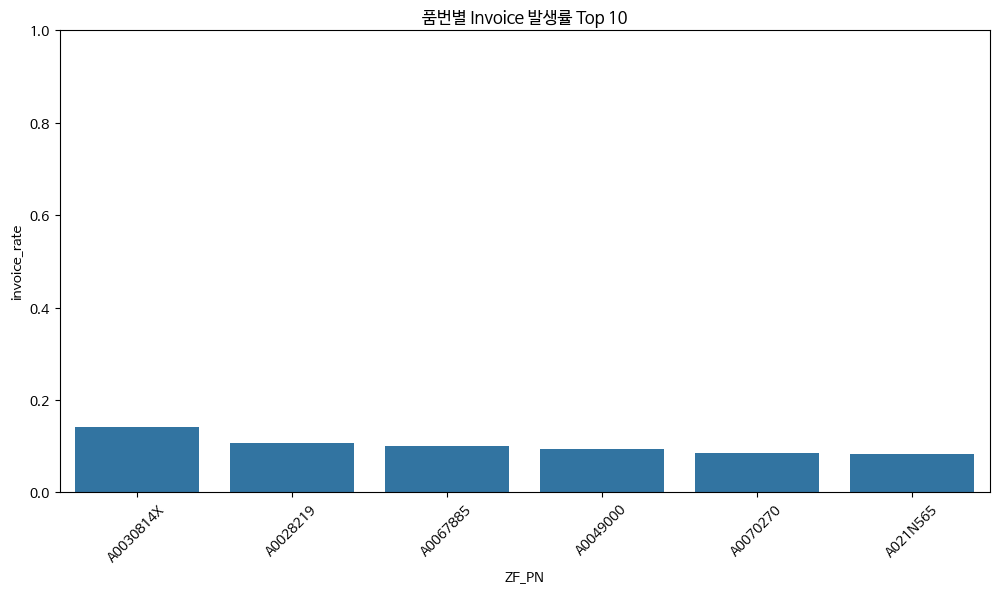

In [21]:
pn_invoice = (
    df.groupby("ZF_PN")
      .agg(
          total_rows=("ZF_PN", "size"),
          invoice_rows=("has_invoice", "sum")
      )
      .reset_index()
)

pn_invoice["invoice_rate"] = pn_invoice["invoice_rows"] / pn_invoice["total_rows"]

top_invoice = pn_invoice[pn_invoice["total_rows"] >= 10].sort_values("invoice_rate", ascending=False).head(10)
print(top_invoice)

plt.figure(figsize=(12,6))
sns.barplot(data=top_invoice, x="ZF_PN", y="invoice_rate")
plt.title("품번별 Invoice 발생률 Top 10")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

In [33]:
df.groupby(["ZF_PN","Quantity"])["has_invoice"].mean()

ZF_PN     Quantity
A0028219  1.600       0.185567
          3.200       0.132692
          4.800       0.077562
          6.400       0.122010
          8.000       0.573770
                        ...   
A021N565  6.720       0.833333
          7.056       0.000000
          10.080      1.000000
          336.000     0.562500
          672.000     0.000000
Name: has_invoice, Length: 117, dtype: float64

In [34]:
df.groupby("Quantity")["has_invoice"].mean()

,has_invoice
Quantity,
1.008,0.075714
1.032,0.000000
1.260,0.375000
1.344,0.192308
1.596,0.000000
...,...
588.000,0.000000
672.000,0.455696
864.000,1.000000


<Axes: xlabel='Quantity', ylabel='ZF_PN'>

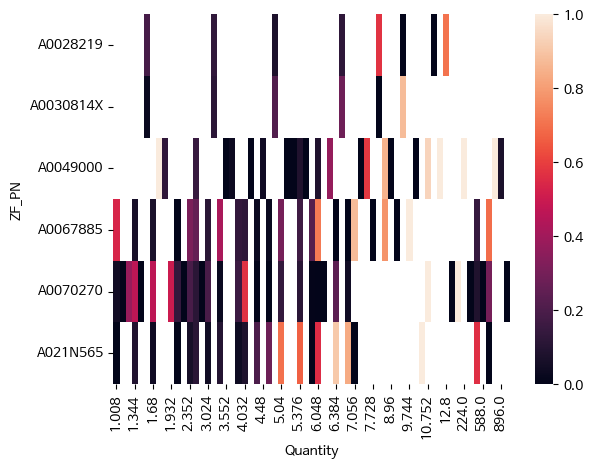

In [35]:
pivot = df.pivot_table(
    values="has_invoice",
    index="ZF_PN",
    columns="Quantity",
    aggfunc="mean"
)

sns.heatmap(pivot)

# 최종 정리

본 연구에서는 공급망 주문 데이터를 활용하여 주문 프로세스의 구조를 이해하고, 향후 주문 및 출하 여부를 예측할 수 있는 가능성을 탐색하기 위해 탐색적 데이터 분석(EDA)을 수행하였다. 데이터는 크게 Forecast, Firm, 그리고 Shipped Invoice의 세 가지 상태를 포함하고 있으며, 이를 통해 주문이 실제 출하로 이어지는 과정을 분석할 수 있다.

먼저 데이터 구조를 확인한 결과, 주문 데이터는 일반적인 공급망 프로세스와 유사한 흐름을 보였다. 즉, 고객의 수요 예측 단계인 Forecast를 시작으로, 실제 주문 확정 단계인 Firm으로 전환되고, 이후 실제 출하 단계인 Shipped Invoice로 이어지는 구조를 가지고 있었다.

EDA 결과 Forecast 데이터는 대부분 실제 출하로 이어지지 않았으며, Forecast는 실제 주문 이전의 수요 예측 단계임을 확인할 수 있었다. 반면 Firm 상태의 주문에서는 약 70% 정도가 실제 Invoice로 이어지는 패턴이 나타났으며, 이는 Firm이 실제 주문 확정 단계임을 의미한다. 따라서 Forecast → Firm → Invoice로 이어지는 공급망 주문 프로세스가 데이터에서도 명확하게 확인되었다.

또한 주문의 물류 특성을 분석하기 위해 Shipping 방식과 Quantity 분포를 분석한 결과, 대부분의 주문은 SEA 운송을 통해 처리되었으며, AIR 운송은 소량 주문에서만 발생하는 패턴을 보였다. 이는 실제 물류 시스템에서 일반적으로 나타나는 구조와 동일하게, SEA는 계획된 대량 운송을 의미하고 AIR는 긴급 소량 운송을 의미하는 것으로 해석할 수 있다.

다음으로 SKU별 수요 패턴을 분석하기 위해 수요 변동성(CV)을 계산하였다. 분석 결과 일부 제품은 매우 안정적인 수요 패턴을 보인 반면, 특정 SKU에서는 매우 높은 수요 변동성이 나타났다. 특히 일부 제품에서는 평균 수요가 높은 동시에 변동성도 높은 패턴이 나타났는데, 이러한 제품은 공급망 관리 측면에서 재고 및 생산 계획에 있어 높은 리스크를 가지는 SKU로 판단된다.

출하 구조를 분석하기 위해 Invoice 단위 데이터를 추가적으로 분석한 결과, 하나의 Invoice에는 평균적으로 약 7~10개의 서로 다른 SKU가 포함되는 것으로 나타났다. 이는 실제 물류 시스템에서 하나의 출하 단위(Shipment)가 여러 제품을 묶어 출하되는 형태의 shipment batch 구조를 가지고 있음을 의미한다.

가장 중요한 분석은 SKU와 주문 수량(Quantity)에 따른 출하 확률을 분석한 부분이다. SKU와 Quantity를 기준으로 Invoice 발생 확률을 계산한 결과, 동일한 SKU와 동일한 주문 수량을 가지는 주문이라도 항상 동일한 결과가 나타나는 것이 아니라, 일부는 출하되고 일부는 출하되지 않는 확률적 패턴이 존재함을 확인하였다. 예를 들어 동일한 SKU와 동일한 Quantity 조합에서도 출하 확률이 0.1 수준인 경우도 있었고 0.8 이상의 높은 확률을 보이는 경우도 존재하였다.

이를 heatmap 형태로 시각화한 결과 SKU와 Quantity의 조합에 따라 출하 확률이 크게 달라지는 패턴이 확인되었다. 일부 SKU와 특정 수량 조합에서는 거의 항상 출하되는 안정적인 패턴이 나타났으며, 반대로 일부 조합에서는 출하 확률이 매우 낮은 패턴도 존재하였다. 또한 동일한 SKU와 동일한 Quantity에서도 출하 여부가 달라지는 경우가 존재했는데, 이는 출하 여부가 단순한 규칙 기반 결정이 아니라 확률적 의사결정 구조를 가진다는 것을 의미한다.

이러한 분석 결과는 본 데이터가 단순히 규칙 기반으로 결정되는 시스템이 아니라 머신러닝 기반 예측 문제로 접근할 수 있는 데이터 구조를 가지고 있음을 보여준다. 만약 SKU와 Quantity가 출하 여부를 완전히 결정하는 1:1 관계였다면 별도의 예측 모델이 필요하지 않았을 것이다. 그러나 동일한 조건에서도 서로 다른 결과가 나타나는 확률적 패턴이 존재하기 때문에, 주문 정보로부터 실제 출하 여부를 예측하는 모델을 구축할 수 있는 가능성이 확인되었다.

따라서 본 연구에서는 다음과 같은 두 가지 예측 문제를 설정할 수 있다.

첫 번째는 Forecast 단계의 주문이 실제 Firm 주문으로 전환될 것인지 예측하는 문제이다. 이는 수요 예측 데이터가 실제 주문으로 이어질 확률을 예측하는 문제로, 공급망에서 생산 계획 및 재고 관리에 매우 중요한 의미를 가진다.

두 번째는 Firm 주문이 실제 출하(Invoice)로 이어질 것인지 예측하는 문제이다. 이는 확정된 주문 중 실제 출하가 이루어질 가능성을 예측하는 문제로, 출하 계획 및 물류 운영 최적화에 활용될 수 있다.

특히 SKU와 Quantity의 조합이 출하 확률에 중요한 영향을 미치는 것으로 나타났기 때문에, 향후 예측 모델에서는 ZF_PN, Quantity, Shipping 방식, 주문 시점과 같은 변수들을 활용하여 출하 여부를 예측하는 모델을 구축할 수 있을 것으로 기대된다

- 결론적으로 본 EDA를 통해 데이터가 실제 공급망 주문 프로세스를 반영하고 있음을 확인하였으며, SKU와 주문 수량에 따른 확률적 출하 패턴이 존재함을 확인하였다. 이를 바탕으로 Forecast → Firm 전환 예측 및 Firm → Invoice 출하 예측이라는 두 가지 머신러닝 기반 예측 문제를 할 수 있지 않을까 생각.